# ΔTb-based Cluster Creation over the Northern Hemisphere (> 60°N)

This script generates the brightness temperature difference (ΔTb) climatology for the period 1988–2022, based on the preprocessed outputs from `Preprocess_dTB.ipynb`. The climatology represents the mean seasonal cycle (i.e., the characteristic temporal shape) of ΔTb for each pixel.

Using this climatological ΔTb, the domain north of 60°N is partitioned into distinct clusters. The optimal number of clusters is determined using the silhouette score. This clustering framework enables the identification and analysis of region-specific regimes, allowing for a better understanding of the spatial variability in snowmelt-related processes.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pdL
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import IncrementalPCA

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")


## Create the land mask for regions north of 60°N

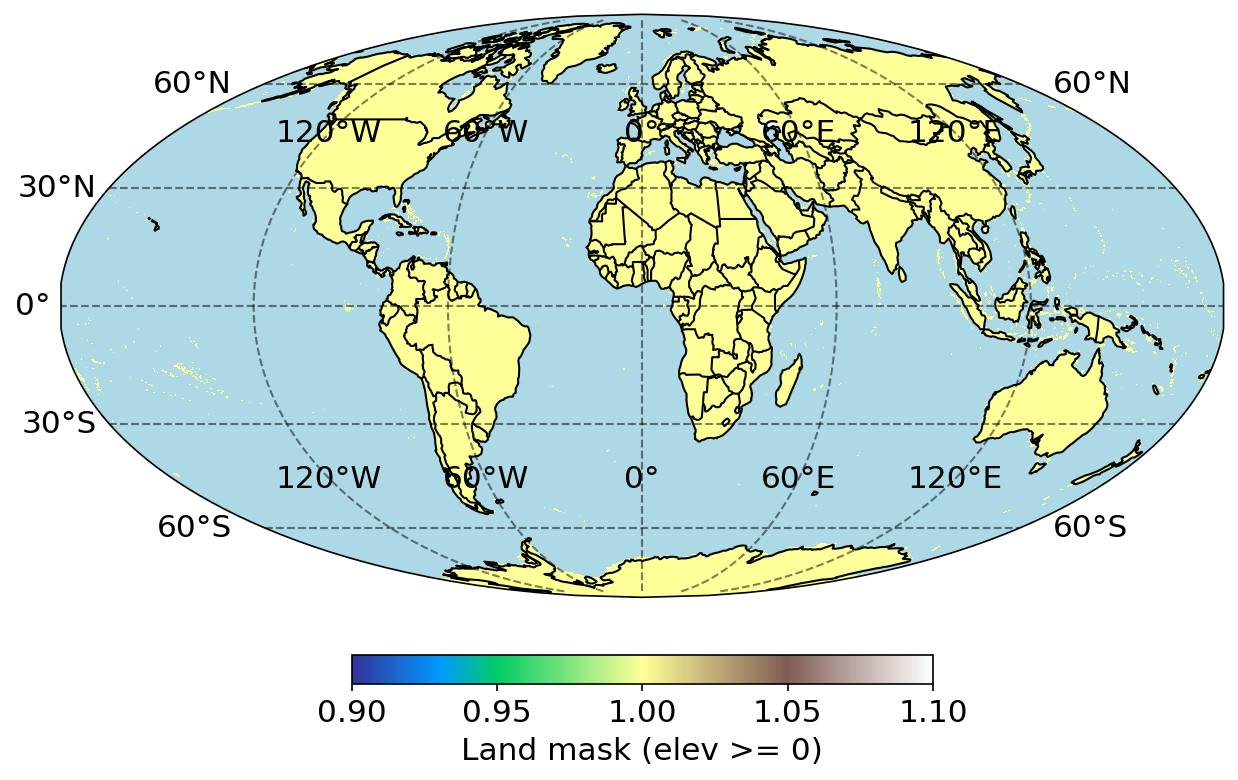

In [2]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

DEM_path = '/home/nayoung/nas_data/DEM'
Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
DEM_25km = nc.Dataset(Find_DEM_File[0])
with nc.Dataset(Find_DEM_File[0]) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Create a function to plot the North Polar region, as the study focuses on areas north of 60°N

In [3]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='neither',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

## 35-year TB difference (19V − 37V) Climatology
To characterize the behavior of TB_diff at each pixel, a 35-year climatology was constructed.  
Daily TB_diff values were reorganized onto a 365-day calendar, and February 29 was excluded in leap years to maintain a consistent temporal framework.  
For each pixel and day of year, climatological values were then calculated from the multi-year mean of valid daily observations within the study domain. Each pixel is represented by a 365-dimensional feature vector describing the climatological seasonal cycle. Each dimension corresponds to a specific day of year (DOY), and its value represents the multi-year mean TB difference averaged across all available years.

In [4]:
TB_path  = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Brightness_Temperature/Final_TB_difference.nc"
Permafrost_waterbody_mask_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Permafrost_waterbody_mask"

START_YEAR, END_YEAR = 1988, 2022
N_FEAT_DOY = 365
N_JOBS = 8        
CHUNK_YEARS = 4     # Number of years to run at once

# To find out if the year is a leap year
def is_leap(y):
    return (y % 4 == 0) and ((y % 100 != 0) or (y % 400 == 0))

# To remove February 29
def doy_index_365(d, leap):
    if not leap:
        return d
    if d < 59:
        return d
    if d == 59:
        return None
    return d - 1

# To mask out remaining invalid values that were not filtered by the land mask
def load_static_mask():
    mask_file = os.path.join(Permafrost_waterbody_mask_dir, "Permafrost_waterbody_mask_25km_1992.nc")
    with nc.Dataset(mask_file) as ds:
        snowice = np.ma.filled(ds["snowice_mask"][:], np.nan)
        water   = np.ma.filled(ds["water_mask"][:],   np.nan)
    return np.isnan(snowice) | np.isnan(water)

def process_one_year(year_idx, start_idx, ndays, tb_path, domain_mask):
    """Return tb_sum_y, tb_cnt_y for one year (already masked outside the domain)"""
    year = START_YEAR + year_idx
    leap = is_leap(year)

    H, W = domain_mask.shape
    tb_sum_y = np.zeros((H, W, N_FEAT_DOY), dtype=np.float32)
    tb_cnt_y = np.zeros((H, W, N_FEAT_DOY), dtype=np.uint16)

    with nc.Dataset(tb_path, 'r') as ds:
        tb_var = ds["tb_diff"]
        tb_var.set_auto_maskandscale(False)
        for d in range(ndays):
            doy = doy_index_365(d, leap)
            if doy is None or doy >= N_FEAT_DOY:
                continue

            arr = tb_var[:, :, start_idx + d].astype("float32")
            arr[arr <= -999990] = np.nan
            arr = arr / 10000.0

            # NaN outside the domain
            arr[~domain_mask] = np.nan

            finite = np.isfinite(arr)
            if not np.any(finite):
                continue

            tb_sum_y[:, :, doy] += np.where(finite, arr, 0.0) 
            tb_cnt_y[:, :, doy] += finite.astype(np.uint16) # Finite = 1, Invalid = 0

    print(f"Year {year} done")
    return tb_sum_y, tb_cnt_y

In [5]:
# Prepare grid and mask
with nc.Dataset(TB_path, 'r') as ds:
    tb_shape = ds["tb_diff"].shape
    if "lat" in ds.variables:
        lat_arr = ds["lat"][:]
    else:
        lat_arr = ds["latitude"][:]
    if "lon" in ds.variables:
        lon_arr = ds["lon"][:]
    else:
        lon_arr = ds["longitude"][:]

    H, W, T = tb_shape
    print("TB_diff shape:", tb_shape)

LON, LAT = np.meshgrid(lon_arr, lat_arr)
invalid_mask = load_static_mask()
domain_mask = (LAT >= 60.0) & (~invalid_mask)

years = np.arange(START_YEAR, END_YEAR + 1)
ndays_list = [366 if is_leap(y) else 365 for y in years]
if sum(ndays_list) != T:
    raise ValueError(f"time mismatch: var={T}, sum(year days)={sum(ndays_list)}")
t_starts = np.cumsum([0] + ndays_list[:-1])

# Create a global accumulation array
tb_sum = np.zeros((H, W, N_FEAT_DOY), dtype=np.float32)
tb_cnt = np.zeros((H, W, N_FEAT_DOY), dtype=np.uint32)

# Chunk-wise parallel processing under memory constraints
n_years = len(years)
for chunk_start in range(0, n_years, CHUNK_YEARS):
    chunk_ids = list(range(chunk_start, min(chunk_start + CHUNK_YEARS, n_years)))
    print(f"\nProcessing years {START_YEAR + chunk_ids[0]}–{START_YEAR + chunk_ids[-1]} ...")

    results = Parallel(n_jobs=N_JOBS, verbose=5)(
        delayed(process_one_year)(
            yi,
            int(t_starts[yi]),
            int(ndays_list[yi]),
            TB_path,
            domain_mask
        )
        for yi in chunk_ids
    )

    # Accumulate chunk results directly into the global sum and discard the list
    for sum_y, cnt_y in results:
        tb_sum += sum_y
        tb_cnt += cnt_y
    del results

# Calculate climatology and save
with np.errstate(invalid="ignore", divide="ignore"):
    tb_clim = tb_sum / tb_cnt
tb_clim[tb_cnt == 0] = np.nan

print("tb_clim computed safely:", tb_clim.shape)

out_nc = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_climatology_1988_2022.nc"
with nc.Dataset(out_nc, "w", format="NETCDF4") as dst:
    dst.createDimension("lat", H)
    dst.createDimension("lon", W)
    dst.createDimension("doy", N_FEAT_DOY)

    vlat = dst.createVariable("lat", "f4", ("lat",))
    vlon = dst.createVariable("lon", "f4", ("lon",))
    vlat[:] = lat_arr
    vlon[:] = lon_arr

    vtb = dst.createVariable("tb_clim", "f4", ("lat", "lon", "doy"), zlib=True, complevel=4)
    vtb[:] = tb_clim

print("Saved climatology to:", out_nc)


TB_diff shape: (120, 1440, 12784)

Processing years 1988–1991 ...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


Year 1988 done
Year 1990 done


[Parallel(n_jobs=8)]: Done   2 out of   4 | elapsed: 14.5min remaining: 14.5min


Year 1989 done
Year 1991 done


...


Processing years 2020–2022 ...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


Year 2020 done
Year 2021 done
Year 2022 done


[Parallel(n_jobs=8)]: Done   3 out of   3 | elapsed: 14.7min finished


tb_clim computed safely: (120, 1440, 365)
Saved climatology to: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_climatology_1988_2022.nc


## Determine the optimal number of clusters (K)
The optimal number of clusters (K) was determined using the silhouette score by evaluating a range of candidate values. A fixed number of training samples were randomly selected from valid pixels using reservoir sampling to ensure unbiased sampling without loading the entire dataset into memory. Prior to clustering, principal component analysis (PCA) was applied to reduce the dimensionality of the climatological features and to retain the dominant variability patterns while suppressing noise.


In [6]:
TB_CLIM_PATH = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_climatology_1988_2022.nc"

N_TRAIN = 20000           # The number of training samples for PCA and KMeans
N_COMPONENTS = 5
k_range = range(2, 11)


# 1. Applying reservoir sampling to the TB-diff climatology
with nc.Dataset(TB_CLIM_PATH, "r") as ds:
    tb = ds["tb_clim"]       # (lat, lon, doy)
    lat_arr = ds["lat"][:]
    lon_arr = ds["lon"][:]

    H = len(lat_arr)
    W = len(lon_arr)
    N_DOY = tb.shape[2]

    print("tb_clim var shape:", tb.shape)

    rng = np.random.default_rng(42)

    sample_feats = None
    sample_coords = None
    n_seen = 0

    for i in range(H):
        row = np.array(tb[i, :, :], dtype=np.float32)   # (W, N_DOY)

        for j in range(W):
            if land_mask_60N_base[i, j] != 1: 
                continue

            prof = row[j, :]
            if np.any(~np.isfinite(prof)):
                continue

            if sample_feats is None:
                sample_feats = np.zeros((N_TRAIN, N_DOY), dtype=np.float32)
                sample_coords = np.zeros((N_TRAIN, 2), dtype=int)

            if n_seen < N_TRAIN:
                sample_feats[n_seen, :] = prof
                sample_coords[n_seen, :] = (i, j)
            else:
                k = rng.integers(0, n_seen + 1)
                if k < N_TRAIN:
                    sample_feats[k, :] = prof
                    sample_coords[k, :] = (i, j)

            n_seen += 1

print(f"Total valid pixels seen: {n_seen}")
if n_seen == 0:
    raise RuntimeError("No valid TB_clim pixels found.")
if n_seen < N_TRAIN:
    sample_feats = sample_feats[:n_seen, :]
    sample_coords = sample_coords[:n_seen, :]
    print(f"Use all {n_seen} pixels for training.")
else:
    print(f"Training sample size fixed to {N_TRAIN}.")


# 2. Apply PCA once before determining the optimal number of clusters
scaler = StandardScaler()
X_train = scaler.fit_transform(sample_feats)

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train)
print("PCA explained variance ratio:", pca.explained_variance_ratio_) # The result shows that the first 5 components capture approximately 97.7% of the total variance
print("PCA explained variance ratio sum:", np.sum(pca.explained_variance_ratio_))


# 3. Determine the optimal number of clusters using the silhouette score
k_range = range(2, 7)
sample_size = 3000
seed_list = [0, 7, 13, 21, 42]

# Calculate labels for each number of clusters
labels_by_k = {}
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_by_k[k] = km.fit_predict(X_train_pca)

# Calculate silhouette scores for each seed
for seed in seed_list:
    sil_scores = []
    for k in k_range:
        sil = silhouette_score(
            X_train_pca, labels_by_k[k],
            sample_size=sample_size,
            random_state=seed
        )
        sil_scores.append(sil)

    print(f"seed={seed}:", dict(zip(k_range, sil_scores)))
    best_k = list(k_range)[int(np.argmax(sil_scores))]
    print(f"Winner: k={best_k}, sil={max(sil_scores):.4f}")

tb_clim var shape: (120, 1440, 365)
Total valid pixels seen: 45866
Training sample size fixed to 20000.
PCA explained variance ratio: [0.5880049  0.24461667 0.11123182 0.01950637 0.01365505]
PCA explained variance ratio sum: 0.97701484


OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 64 or lower


seed=0: {2: 0.33256983757019043, 3: 0.3437809646129608, 4: 0.3697736859321594, 5: 0.31443360447883606, 6: 0.33342400193214417}
Winner: k=4, sil=0.3698
seed=7: {2: 0.32986417412757874, 3: 0.3402618169784546, 4: 0.3683108687400818, 5: 0.3124683201313019, 6: 0.33082717657089233}
Winner: k=4, sil=0.3683
seed=13: {2: 0.321435809135437, 3: 0.3320677876472473, 4: 0.3607909381389618, 5: 0.30577903985977173, 6: 0.3256109654903412}
Winner: k=4, sil=0.3608
seed=21: {2: 0.33171987533569336, 3: 0.3416789472103119, 4: 0.3664998710155487, 5: 0.30592411756515503, 6: 0.32215210795402527}
Winner: k=4, sil=0.3665
seed=42: {2: 0.3221910893917084, 3: 0.33066678047180176, 4: 0.3492882549762726, 5: 0.29678240418434143, 6: 0.312966525554657}
Winner: k=4, sil=0.3493


## Cluster Map from TB-Difference Climatology
Clusters were derived from all valid pixels of the TB-difference climatology, using MiniBatchKMeans and Incremental PCA to ensure memory-efficient computation.

In [7]:
def iter_valid_profiles(ds, land_mask):
    tb = ds["tb_clim"]  # (lat, lon, doy)
    H, W, N_DOY = tb.shape
    for i in range(H):
        row = np.array(tb[i, :, :], dtype=np.float32)  # (W, N_DOY)
        for j in range(W):
            if land_mask_60N_base[i, j] != 1: 
                continue
            prof = row[j, :]
            if np.any(~np.isfinite(prof)):
                continue
            yield i, j, prof

def batcher(gen, batch_size):
    X, IJ = [], []
    for i, j, prof in gen:
        X.append(prof)
        IJ.append((i, j))
        if len(X) == batch_size:
            yield np.stack(X, axis=0), np.array(IJ, dtype=np.int32)
            X, IJ = [], []
    if X:
        yield np.stack(X, axis=0), np.array(IJ, dtype=np.int32)

In [8]:
TB_CLIM_PATH = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_climatology_1988_2022.nc"

N_CLUSTERS = best_k
N_COMPONENTS = 5
BATCH = 4096
RANDOM_STATE = 42

with nc.Dataset(TB_CLIM_PATH, "r") as ds:
    tb = ds["tb_clim"]
    lat_arr = ds["lat"][:]
    lon_arr = ds["lon"][:]
    H, W, N_DOY = tb.shape

    if land_mask_60N_base.shape != (H, W):
        raise ValueError(f"Mask shape mismatch: mask={land_mask_60N_base.shape}, tb grid={(H, W)}")

    print("tb_clim shape:", tb.shape)

    # 1. Fit StandardScaler incrementally on all valid pixels using partial_fit to handle large datasets
    scaler = StandardScaler(with_mean=True, with_std=True)

    n_total = 0
    for Xb, _ in batcher(iter_valid_profiles(ds, land_mask_60N_base), BATCH):
        scaler.partial_fit(Xb)
        n_total += Xb.shape[0]
    if n_total == 0:
        raise RuntimeError("No valid pixels found.")
    print("Total valid pixels used (ALL):", n_total)

    # 2. Fit IncrementalPCA on all valid pixels in batches to handle large datasets without loading all data into memory
    ipca = IncrementalPCA(n_components=N_COMPONENTS, batch_size=BATCH)

    for Xb, _ in batcher(iter_valid_profiles(ds, land_mask_60N_base), BATCH):
        Xz = scaler.transform(Xb)
        ipca.partial_fit(Xz)

    print("IncrementalPCA fitted on ALL valid pixels.")

    # 3. Fit MiniBatchKMeans in batches on scaled and PCA-transformed data to handle large datasets efficiently
    mbk = MiniBatchKMeans(
        n_clusters=N_CLUSTERS,
        random_state=RANDOM_STATE,
        batch_size=BATCH,
        n_init="auto"
    )

    for Xb, _ in batcher(iter_valid_profiles(ds, land_mask_60N_base), BATCH):
        Xz = scaler.transform(Xb)
        Z = ipca.transform(Xz)
        mbk.partial_fit(Z)

    print("MiniBatchKMeans fitted on ALL valid pixels.")

    # 4. Generate the full TB cluster map by applying the trained scaler, PCA, and MiniBatchKMeans in a batch-wise manner
    tb_cluster_map = np.full((H, W), -1, dtype=np.int16)

    for Xb, IJb in batcher(iter_valid_profiles(ds, land_mask_60N_base), BATCH):
        Xz = scaler.transform(Xb)
        Z = ipca.transform(Xz)
        labs = mbk.predict(Z).astype(np.int16)
        for t in range(len(labs)):
            i, j = IJb[t]
            tb_cluster_map[i, j] = labs[t]

    valid_clusters = np.unique(tb_cluster_map[tb_cluster_map >= 0])
    print("Cluster map created. Unique clusters:", valid_clusters)



tb_clim shape: (120, 1440, 365)
Total valid pixels used (ALL): 45866
IncrementalPCA fitted on ALL valid pixels.
MiniBatchKMeans fitted on ALL valid pixels.
Cluster map created. Unique clusters: [0 1 2 3]


In [9]:
out_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc"
TB_diff_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Brightness_Temperature/Final_TB_difference.nc"

with nc.Dataset(TB_diff_path, "r") as ds:
    lat = ds["lat"][:]
    lon = ds["lon"][:]

nlat = np.shape(lat)[0]
nlon = np.shape(lon)[0]

with nc.Dataset(out_path, "w", format="NETCDF4") as ds:
    # dimensions
    ds.createDimension("lat", nlat)
    ds.createDimension("lon", nlon)

    # coordinate variables
    lat_var = ds.createVariable("lat", "f4", ("lat",))
    lon_var = ds.createVariable("lon", "f4", ("lon",))
    lat_var[:] = lat.astype(np.float32)
    lon_var[:] = lon.astype(np.float32)

    lat_var.units = "degrees_north"
    lon_var.units = "degrees_east"
    lat_var.standard_name = "latitude"
    lon_var.standard_name = "longitude"

    # data variable 
    tb_cluster_var = ds.createVariable(
        "TB_cluster",
        "i2",                 
        ("lat", "lon"),
        zlib=True,
        complevel=4,
        fill_value=-1
    )

    tb_cluster_var[:] = tb_cluster_map.astype(np.int16)
    tb_cluster_var.long_name = "TB difference regime cluster map"
    tb_cluster_var.flag_values = np.array([-1, 1, 2, 3], dtype=np.int16)
    tb_cluster_var.flag_meanings = "missing cluster1 cluster2 cluster3"

print("Saved:", out_path)


Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc


## Plot the cluster map to visualize its distribution

### Figure 1a. Spatial patterns of TB-difference regime clusters

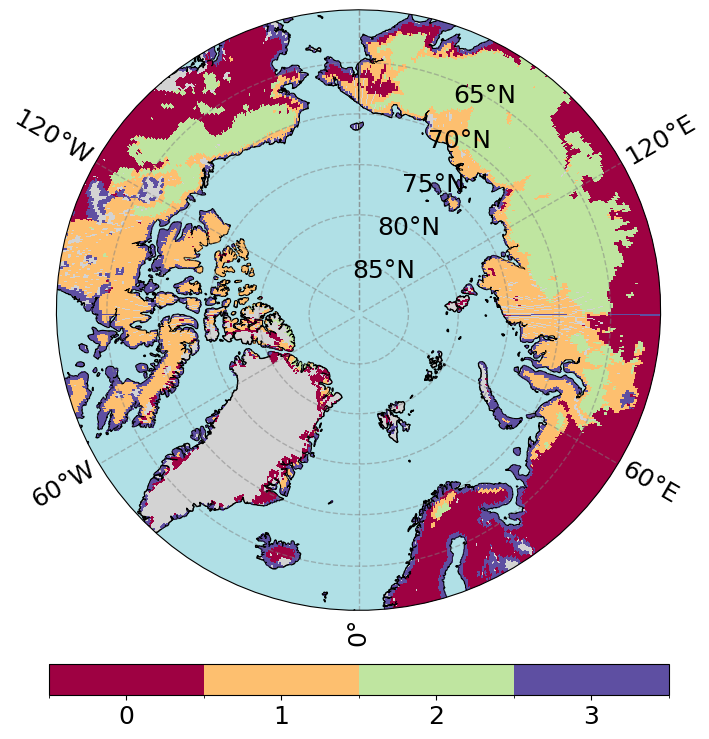

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm

TB_cluster_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc"
with nc.Dataset(TB_cluster_path, "r") as ds:
    tb_cluster_map = ds["TB_cluster"][:]

    # Apply land mask
    tb_cluster_map = np.where(land_mask_60N_base == 1, tb_cluster_map, -1)

domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)
domain_lat_60N = domain_lat[domain_lat[:,0] >= 60.0]
domain_lon_60N = domain_lon[domain_lat[:,0] >= 60.0, :]

bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
ticks = [0, 1, 2, 3]
ticklabels = ['0', '1', '2', '3']
fig, ax = plot_Northpole(domain_lon_60N, domain_lat_60N, np.where(tb_cluster_map==-1, np.nan, tb_cluster_map), label_title=None, cmap = 'Spectral', bounds=bounds, ticks=ticks, ticklabels=ticklabels)

# Save the plot
fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/Figure_1a.png", dpi=300, bbox_inches="tight")


### Figure 1b. Cluster-wise mean seasonal cycles of TB-difference

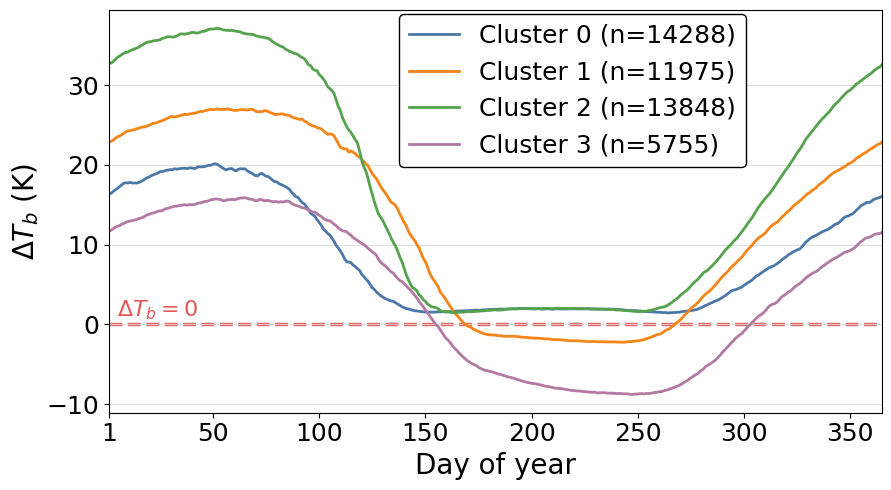

In [11]:
def plot_tb_difference_profiles(tb_clim, tb_cluster_map, min_pixels=100):
    H, W, N_DOY = tb_clim.shape
    doy = np.arange(1, N_DOY + 1)

    cluster_ids = np.unique(tb_cluster_map[np.isfinite(tb_cluster_map)]).astype(int)
    cluster_ids = [cid for cid in sorted(cluster_ids) if cid != -1]

    # Color palette
    palette = ["#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756", "#72B7B2"]
    colors = {cid: palette[i % len(palette)] for i, cid in enumerate(cluster_ids)}

    # Mean seasonal cycle
    fig, ax = plt.subplots(figsize=(11, 5))

    # Highlight the baseline (ΔTb = 0)
    ax.axhline(0, color='#E45756', linestyle='--', linewidth=2.5, alpha=0.9, zorder=0)

    # Add label
    ax.text(5, 1.0, r"$\Delta T_b = 0$", fontsize=16, color='#E45756')   

    for cid in cluster_ids:
        mask = (tb_cluster_map == cid)
        n_pix = np.count_nonzero(mask)
        if n_pix < min_pixels:
            continue
        dTB_mean = np.nanmean(tb_clim[mask, :], axis=0)
        ax.plot(doy, dTB_mean, lw=2.0, color=colors[cid], label=f"Cluster {cid} (n={n_pix})")

    ax.set_xlabel("Day of year", fontsize=20)
    ax.set_ylabel(r"$\Delta T_b$ (K)", fontsize=20)
    ax.set_xlim(1, N_DOY)
    ax.set_xticks([1,50,100,150,200,250,300,350])
    ax.tick_params(axis="both", labelsize=18)

    ax.grid(axis="y", color="0.85", lw=0.6)  
    ax.legend(loc="center", frameon=True, facecolor="white", edgecolor="black", framealpha=1.0, bbox_to_anchor=(0.6, 0.8), fontsize=18)
    fig.tight_layout(rect=[0, 0, 0.82, 1])
    plt.show()

    return fig

fig = plot_tb_difference_profiles(tb_clim, tb_cluster_map)
fig.savefig(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/Figure_1b.png", dpi=300, bbox_inches="tight")
